In [10]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns



# Download NLTK stopwords (runs once)
nltk.download('stopwords', quiet=True)

True

In [ ]:
# Load sentiment data using the custom load function
def load_sentiment_data():
    """
    Automatically loads a sentiment analysis dataset (Amazon reviews).
    Returns a pandas DataFrame with columns 'review' and 'label'
    (1 = positive, 0 = negative).
    """
    url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/amazon_reviews.csv"
    df = pd.read_csv(url)
    # Ensure column names
    df.columns = ['review', 'label']
    return df

df = load_sentiment_data()

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['label'].value_counts())

Dataset loaded successfully!
Shape: (8, 2)

First 5 rows:
                                              review  label
0  This movie is absolutely fantastic! Highly rec...      1
1              Terrible waste of time. Do not watch.      0
2            Amazing plot and great acting. Love it!      1
3         Horrible cinematography and bad storyline.      0
4        One of the best films I have seen in years.      1

Class distribution:
label
1    4
0    4
Name: count, dtype: int64


In [18]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(clean_text)

print("Sample original review:")
print(df['review'].iloc[0])
print("\nSample cleaned review:")
print(df['cleaned_review'].iloc[0])

Sample original review:
This movie is absolutely fantastic! Highly recommended.

Sample cleaned review:
movie absolutely fantastic highly recommended


In [17]:
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 6
Testing samples: 2


In [19]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF training matrix shape: {X_train_tfidf.shape}")

TF-IDF training matrix shape: (6, 45)


In [21]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

Accuracy: 0.5000
ROC-AUC: 0.5000

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         1
    Positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



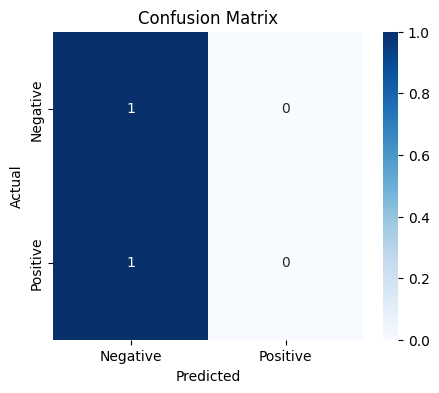

In [23]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

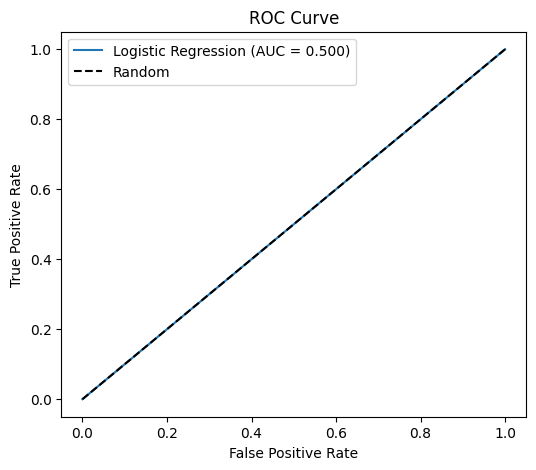

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

top_pos_idx = coefs.argsort()[-10:][::-1]
top_neg_idx = coefs.argsort()[:10]

print("Top positive words:")
for idx in top_pos_idx:
    print(f"{feature_names[idx]}: {coefs[idx]:.4f}")

print("\nTop negative words:")
for idx in top_neg_idx:
    print(f"{feature_names[idx]}: {coefs[idx]:.4f}")

Top positive words:
movie: 0.2363
excellent movie: 0.1535
emotional: 0.1535
emotional depth: 0.1535
movie emotional: 0.1535
depth: 0.1535
excellent: 0.1535
movie absolutely: 0.1347
highly: 0.1347
recommended: 0.1347

Top negative words:
bad: -0.1507
bad storyline: -0.1507
completely dull: -0.1507
completely: -0.1507
cinematography bad: -0.1507
cinematography: -0.1507
boring throughout: -0.1507
boring: -0.1507
dull: -0.1507
horrible cinematography: -0.1507


In [26]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    vec = tfidf.transform([cleaned])
    prob = model.predict_proba(vec)[0][1]
    pred = model.predict(vec)[0]
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment} (confidence: {prob:.4f})")

predict_sentiment("I absolutely love this product! Works great.")
predict_sentiment("Terrible quality, very disappointed.")

Review: I absolutely love this product! Works great.
Sentiment: Positive (confidence: 0.5551)
Review: Terrible quality, very disappointed.
Sentiment: Negative (confidence: 0.4595)
